In [87]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import inspect
import astrodata
from astrodata import open as ad_open
from geminidr.gmos.primitives_gmos_spect import GMOSSpect
from gempy.utils import logutils
import os
import glob
import nest_asyncio
nest_asyncio.apply()
from datetime import datetime, date
import matplotlib.pyplot as plt
import copy
from astropy.io import fits
from scipy.signal import correlate
import copy
import itertools
from astropy.modeling.models import Chebyshev2D
import pandas as pd
from collections import OrderedDict

In [56]:
# Useful tools for working with DRAGONS
# Use with the dragonsenv environment
# Bryan Miller

import astrodata
import gemini_instruments
from recipe_system.reduction.coreReduce import Reduce
from gempy.adlibrary import dataselect

from scipy.interpolate import BSpline
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits as pyfits

# from rebin_spec_test import wave_rebin


def drdisplay(image):
    """Display an image using Reduce"""
    display = Reduce()
    display.files = [image]
    display.recipename = 'display'
    display.runr()


def reduce(flist, inter=False):
    """Reduction with Reduce"""
    result = Reduce()
    result.files.extend(flist)
    if inter:
        result.uparms = dict([('interactive', inter)])
    result.runr()
    return result


def specplot(fitsfile, wavelen=None):
    ad = astrodata.open(fitsfile)
    # ad.info()

    data = ad[0].data
    wavelength = ad[0].wcs(np.arange(data.size)).astype(np.float32)
    units = ad[0].wcs.output_frame.unit[0]
    # print(wavelength)

    if wavelen is None:
        wave_min = 0.0
        wave_max = 10000.
    else:
        wave_min = wavelen[0]
        wave_max = wavelen[1]
    ii = np.where(np.logical_and(wavelength > wave_min, wavelength < wave_max))[0]

    # add aperture number and location in the title.
    # check that plt.xlabel call.  Not sure it's right, it works though.
    plt.xlabel(f'Wavelength ({units})')
    plt.ylabel(f'Signal ({ad[0].hdr["BUNIT"]})')
    plt.plot(wavelength[ii], data[ii])
    # plt.savefig('ngc1800_dragons.png')
    plt.show()


def sensfunc_plot(fitsfile):
    ad = astrodata.open(fitsfile)

    sensfunc = ad[0].SENSFUNC

    order = sensfunc.meta['header'].get('ORDER', 3)
    func = BSpline(sensfunc['knots'].data, sensfunc['coefficients'].data, order)
    std_wave_unit = sensfunc['knots'].unit
    std_flux_unit = sensfunc['coefficients'].unit

    w1 = ad[0].wcs(0)
    w2 = ad[0].wcs(ad[0].data.size)

    x = np.arange(w1, w2)
    plt.xlabel(f'Wavelength ({std_wave_unit})')
    plt.ylabel(f'{std_flux_unit}')
    plt.plot(x, func(x))
    plt.show()


def imshow(image, n_ext, min=None, max=None, scale='sqrt'):

    hdu = pyfits.open(image)
    # hdu.info()
    next = len(hdu)
    print(next)

    array = hdu[n_ext].data

    if min is None:
        min = np.min(array)
    if max is None:
        max = np.max(array)

    plt.figure(figsize=(10, 10))
    plt.imshow(array, origin='lower', vmin=min, vmax=max, cmap='gray_r')
    plt.show()

    hdu.close()

In [57]:
# Set paths
root_dir = os.path.join(os.environ['HOME'], 'research', 'neighborhood_watch', 'G-2025B-0505-V')
print(root_dir)
raw_path = os.path.join(root_dir, 'raw')
proc_path = os.path.join(root_dir, 'dragons_v2')
print(raw_path)
print(proc_path)

/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V
/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw
/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2


In [58]:
# calibration service
from recipe_system import cal_service

# caldb = cal_service.set_local_database()
# caldb.init()

caldb = cal_service.LocalDB(os.path.join(proc_path, 'g25B_0505v_calib.db'))
caldb.init()

LocalManagerError: Database file exists and wipe=True was not specified

In [ ]:
# get file list
all_files = glob.glob(raw_path + '/*.fits')
all_files.sort()

### Now, find the arc files, and look into what's going on when they get reduced.

In [ ]:
# Reduce arcs for galaxies
sci_arcs = dataselect.select_data(all_files, ['ARC'], [], dataselect.expr_parser('ut_date=="2025-9-28"'))
#sci_arcs.append(std_arcs[2])
for arc in sci_arcs:
    print(arc)

        Use numpy.iterable() instead. [gwcs.coordinate_frames]


/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0035.fits
/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0045.fits
/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0052.fits
/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0056.fits
/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0059.fits


In [ ]:
!showrecipes /Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0035.fits

        Use numpy.iterable() instead. [gwcs.coordinate_frames]
Recipe not provided, default recipe (makeProcessedArc) will be used.
Input file: /Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw/S20250928S0035.fits
Input tags: ['SOUTH', 'UNPREPARED', 'SIDEREAL', 'GMOS', 'ARC', 'LS', 'RAW', 'CAL', 'SPECT', 'GEMINI']
Input mode: sq
Input recipe: makeProcessedArc
Matched recipe: geminidr.gmos.recipes.sq.recipes_ARC_LS_SPECT::makeProcessedArc
Recipe location: /Users/elliottburdett/miniconda3/envs/dragonz_new/lib/python3.12/site-packages/geminidr/gmos/recipes/sq/recipes_ARC_LS_SPECT.py
Recipe tags: {'GMOS', 'ARC', 'LS', 'SPECT'}
Primitives used: 
   p.prepare()
   p.addDQ()
   p.addVAR(read_noise=True)
   p.overscanCorrect()
   p.ADUToElectrons()
   p.addVAR(poisson_noise=True)
   p.mosaicDetectors()
   p.determineWavelengthSolution()
   p.determineDistortion()
   p.storeProcessedArc()
   p.writeOutputs()


In [63]:
ad_arcs = [ad_open(f) for f in sci_arcs]
p = GMOSSpect(ad_arcs)

        Use numpy.iterable() instead. [gwcs.coordinate_frames]


In [64]:
p.prepare()
p.addDQ()
p.addVAR(read_noise=True)
p.overscanCorrect()
p.ADUToElectrons()
p.addVAR(poisson_noise=True)
p.mosaicDetectors()

        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]


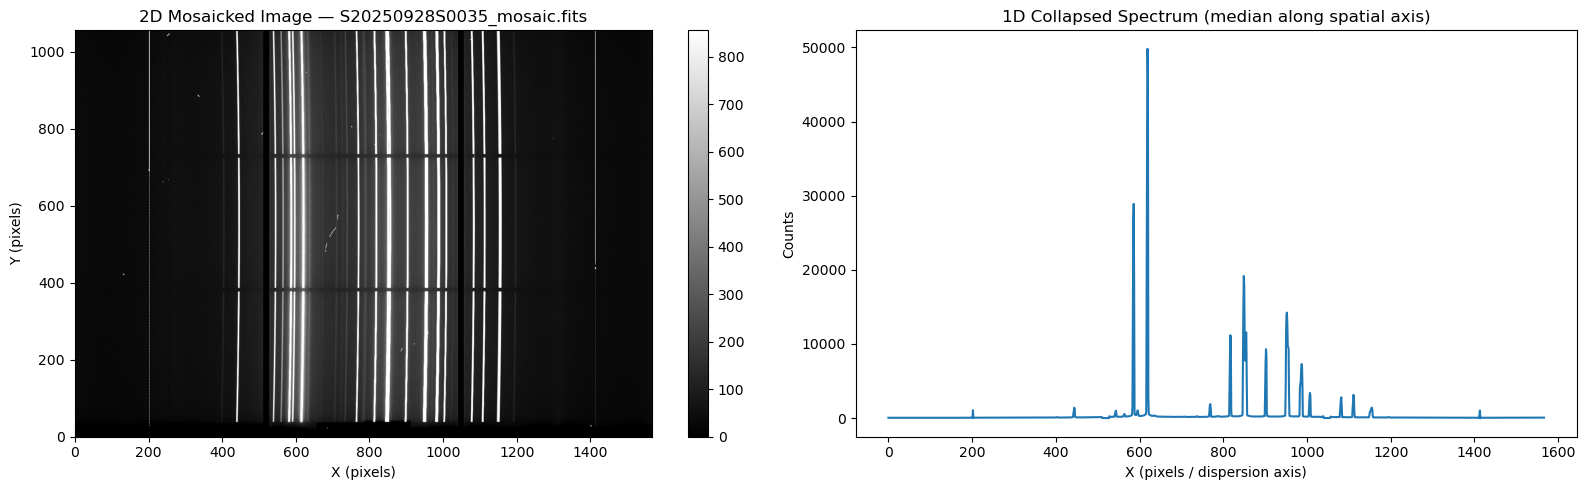

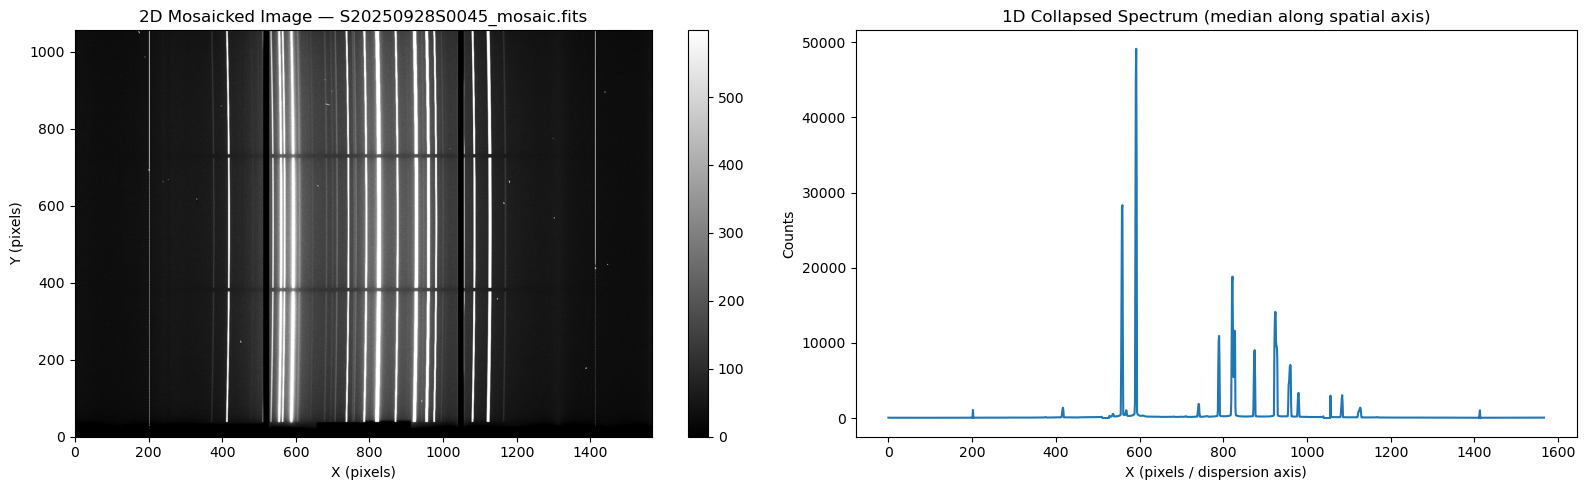

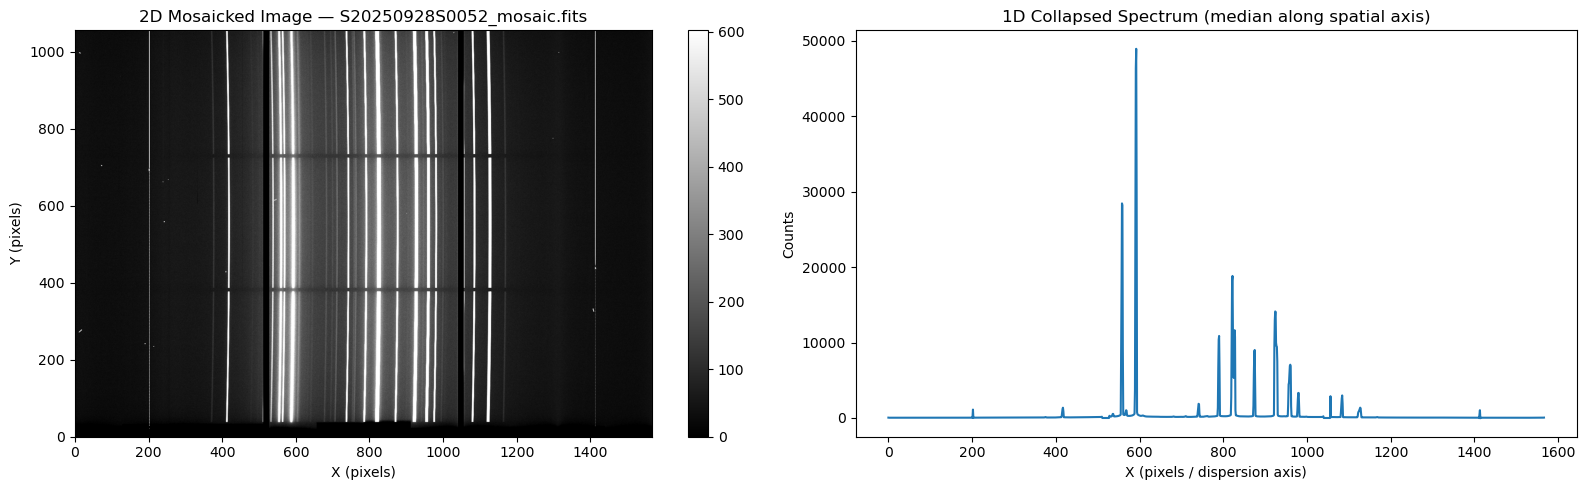

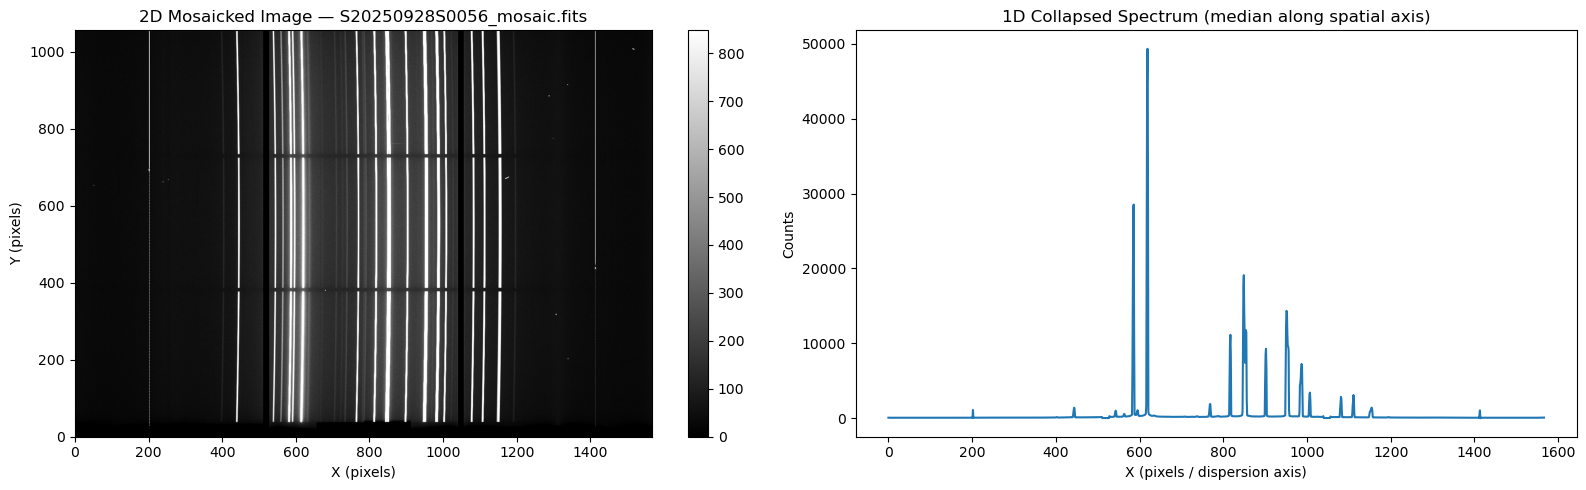

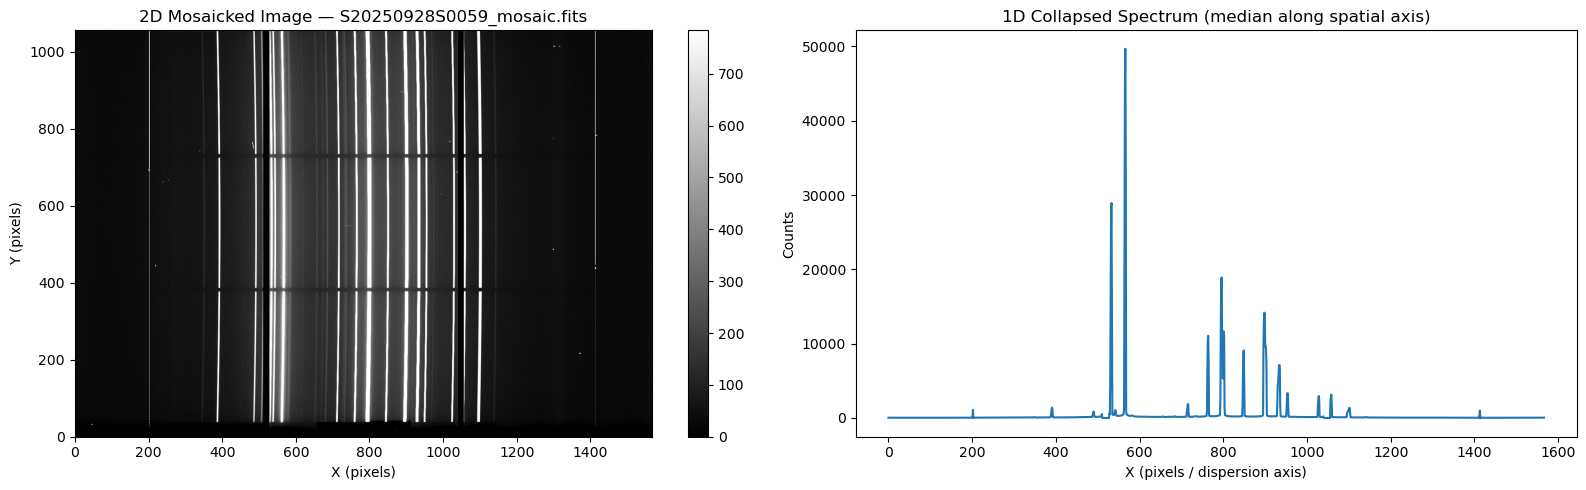

In [ ]:
for i in range(len(sci_arcs)):
    ad = p.streams['main'][i]
    ext = ad[0]  # since it's been mosaiced

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    data = ext.data
    vmin, vmax = np.percentile(data, [5, 95])
    im = axes[0].imshow(data, origin='lower', aspect='auto', vmin=vmin, vmax=vmax, cmap='gray')
    axes[0].set_title(f'2D Mosaicked Image — {ad.filename}')
    axes[0].set_xlabel('X (pixels)')
    axes[0].set_ylabel('Y (pixels)')
    plt.colorbar(im, ax=axes[0])

    spectrum = np.median(data, axis=0)  # collapse along spatial axis
    axes[1].plot(spectrum)
    axes[1].set_title('1D Collapsed Spectrum (median along spatial axis)')
    axes[1].set_xlabel('X (pixels / dispersion axis)')
    axes[1].set_ylabel('Counts')

    plt.tight_layout()
    plt.show()

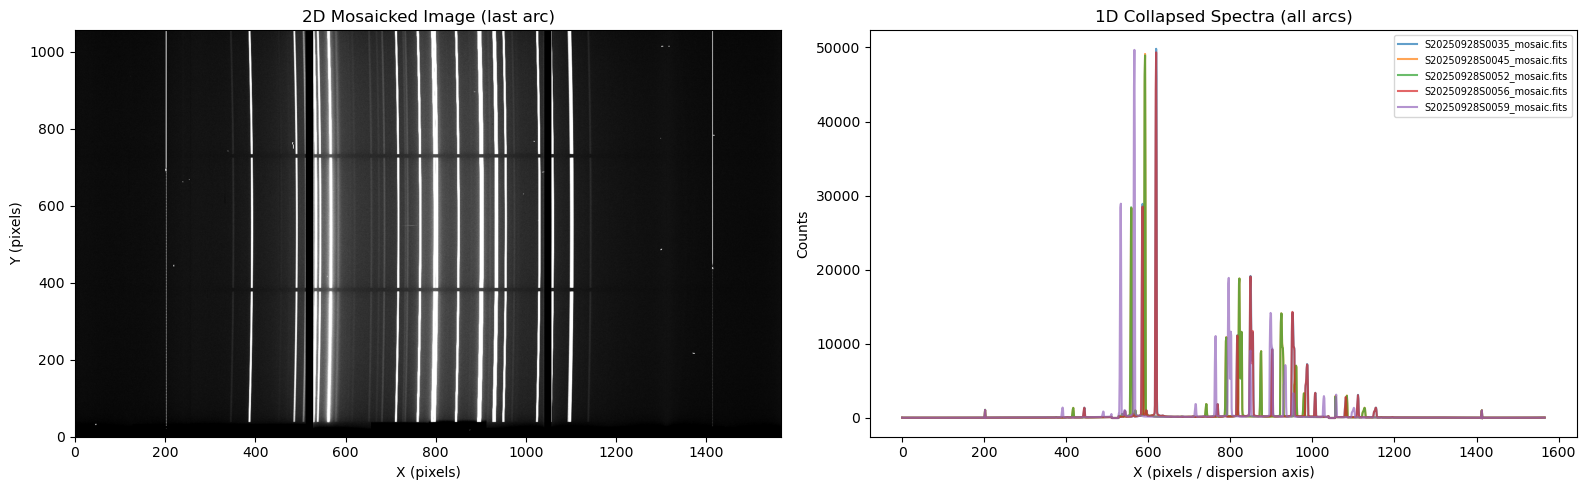

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i in range(len(sci_arcs)):
    ad = p.streams['main'][i]
    ext = ad[0]
    data = ext.data
    
    vmin, vmax = np.percentile(data, [5, 95])
    axes[0].imshow(data, origin='lower', aspect='auto', vmin=vmin, vmax=vmax, cmap='gray')
    axes[0].set_title('2D Mosaicked Image (last arc)')
    axes[0].set_xlabel('X (pixels)')
    axes[0].set_ylabel('Y (pixels)')
    
    spectrum = np.median(data, axis=0)
    axes[1].plot(spectrum, alpha=0.7, label=ad.filename)

axes[1].set_title('1D Collapsed Spectra (all arcs)')
axes[1].set_xlabel('X (pixels / dispersion axis)')
axes[1].set_ylabel('Counts')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
param_grid = {
    'order':   [3, 4, 5], #3
    'nsum':    [5, 10, 20], #10
    'min_snr': [5, 10], #10
}

keys, values = zip(*param_grid.items())
permutations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Testing {len(permutations)} parameter combinations...")

results = []

mosaicked_ads = [copy.deepcopy(ad) for ad in p.streams['main']]

for params in permutations:
    fresh_ads = [copy.deepcopy(ad) for ad in mosaicked_ads]
    
    # Strip HISTORY to avoid provenance conflict on deepcopied objects
    for ad in fresh_ads:
        try:
            del ad.HISTORY
        except AttributeError:
            pass
    
    p_test = GMOSSpect(fresh_ads)
    
    try:
        p_test.determineWavelengthSolution(**params)
        
        for ad in p_test.streams['main']:
            wavecal = ad[0].WAVECAL
            peaks = np.array(wavecal['peaks'])
            wavelengths = np.array(wavecal['wavelengths'])
            
            coeffs = np.polyfit(peaks, wavelengths, deg=params['order'])
            fitted = np.polyval(coeffs, peaks)
            residuals = wavelengths - fitted
            rms = np.std(residuals)
            
            results.append({
                'params': params,
                'filename': ad.filename,
                'peaks': peaks,
                'wavelengths': wavelengths,
                'residuals': residuals,
                'rms': rms,
                'n_lines': len(peaks),
            })
            
    except Exception as e:
        print(f"FAILED {params}: {e}")

Testing 18 parameter combinations...


        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_

In [ ]:
results.sort(key=lambda x: x['rms']) # sort by rms ascending

In [62]:
print(p.params['determineWavelengthSolution'])

OrderedDict({'order': 3, 'lsigma': 3.0, 'hsigma': 3.0, 'niter': 3, 'suffix': '_wavelengthSolutionDetermined', 'center': None, 'nsum': 10, 'min_snr': 10.0, 'min_sep': 2.0, 'weighting': 'local', 'fwidth': None, 'central_wavelength': None, 'dispersion': None, 'linelist': None, 'in_vacuo': False, 'debug_min_lines': '15,20', 'debug_alternative_centers': False, 'interactive': False, 'combine_method': 'mean', 'verbose': False, 'nbright': 0})


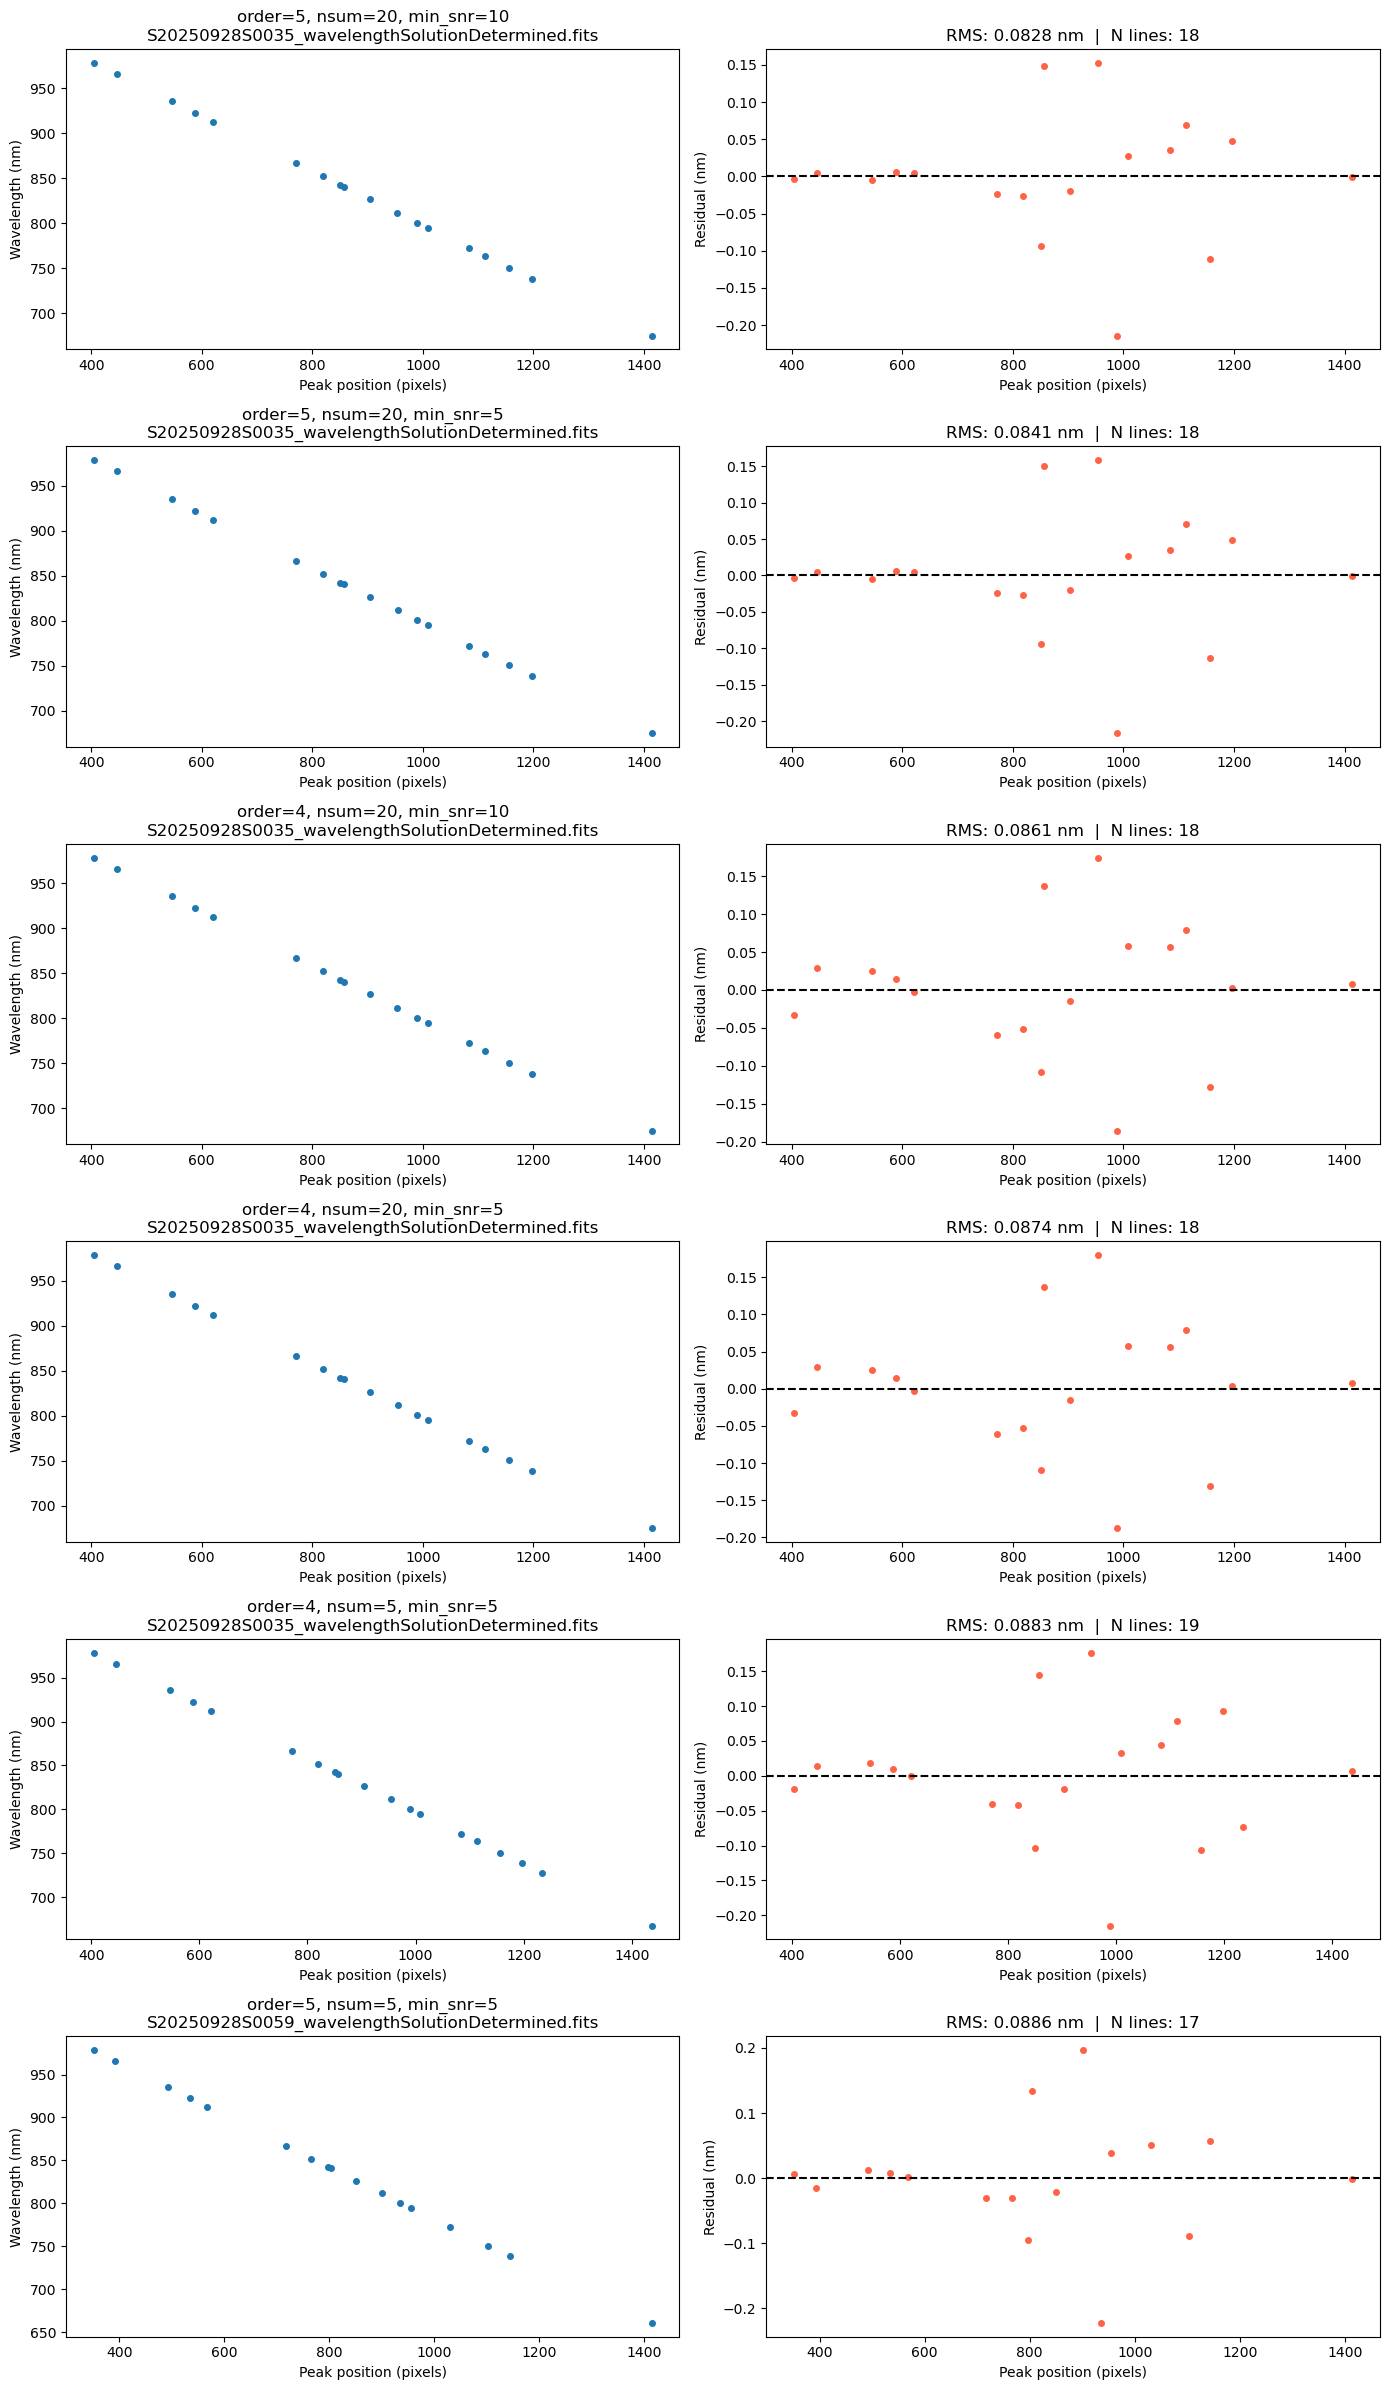

In [ ]:
top_n = 6 # plot the top N results
fig, axes = plt.subplots(top_n, 2, figsize=(14, 4 * top_n))

for idx, r in enumerate(results[:top_n]):
    p_ = r['params']
    label = f"order={p_['order']}, nsum={p_['nsum']}, min_snr={p_['min_snr']}"
    
    # Wavelength solution
    axes[idx, 0].plot(r['peaks'], r['wavelengths'], 'o', markersize=4)
    axes[idx, 0].set_xlabel('Peak position (pixels)')
    axes[idx, 0].set_ylabel('Wavelength (nm)')
    axes[idx, 0].set_title(f'{label}\n{r["filename"]}')
    
    # Residuals
    axes[idx, 1].plot(r['peaks'], r['residuals'], 'o', markersize=4, color='tomato')
    axes[idx, 1].axhline(0, color='k', linestyle='--')
    axes[idx, 1].set_xlabel('Peak position (pixels)')
    axes[idx, 1].set_ylabel('Residual (nm)')
    axes[idx, 1].set_title(f'RMS: {r["rms"]:.4f} nm  |  N lines: {r["n_lines"]}')

plt.tight_layout()
plt.show()

        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]


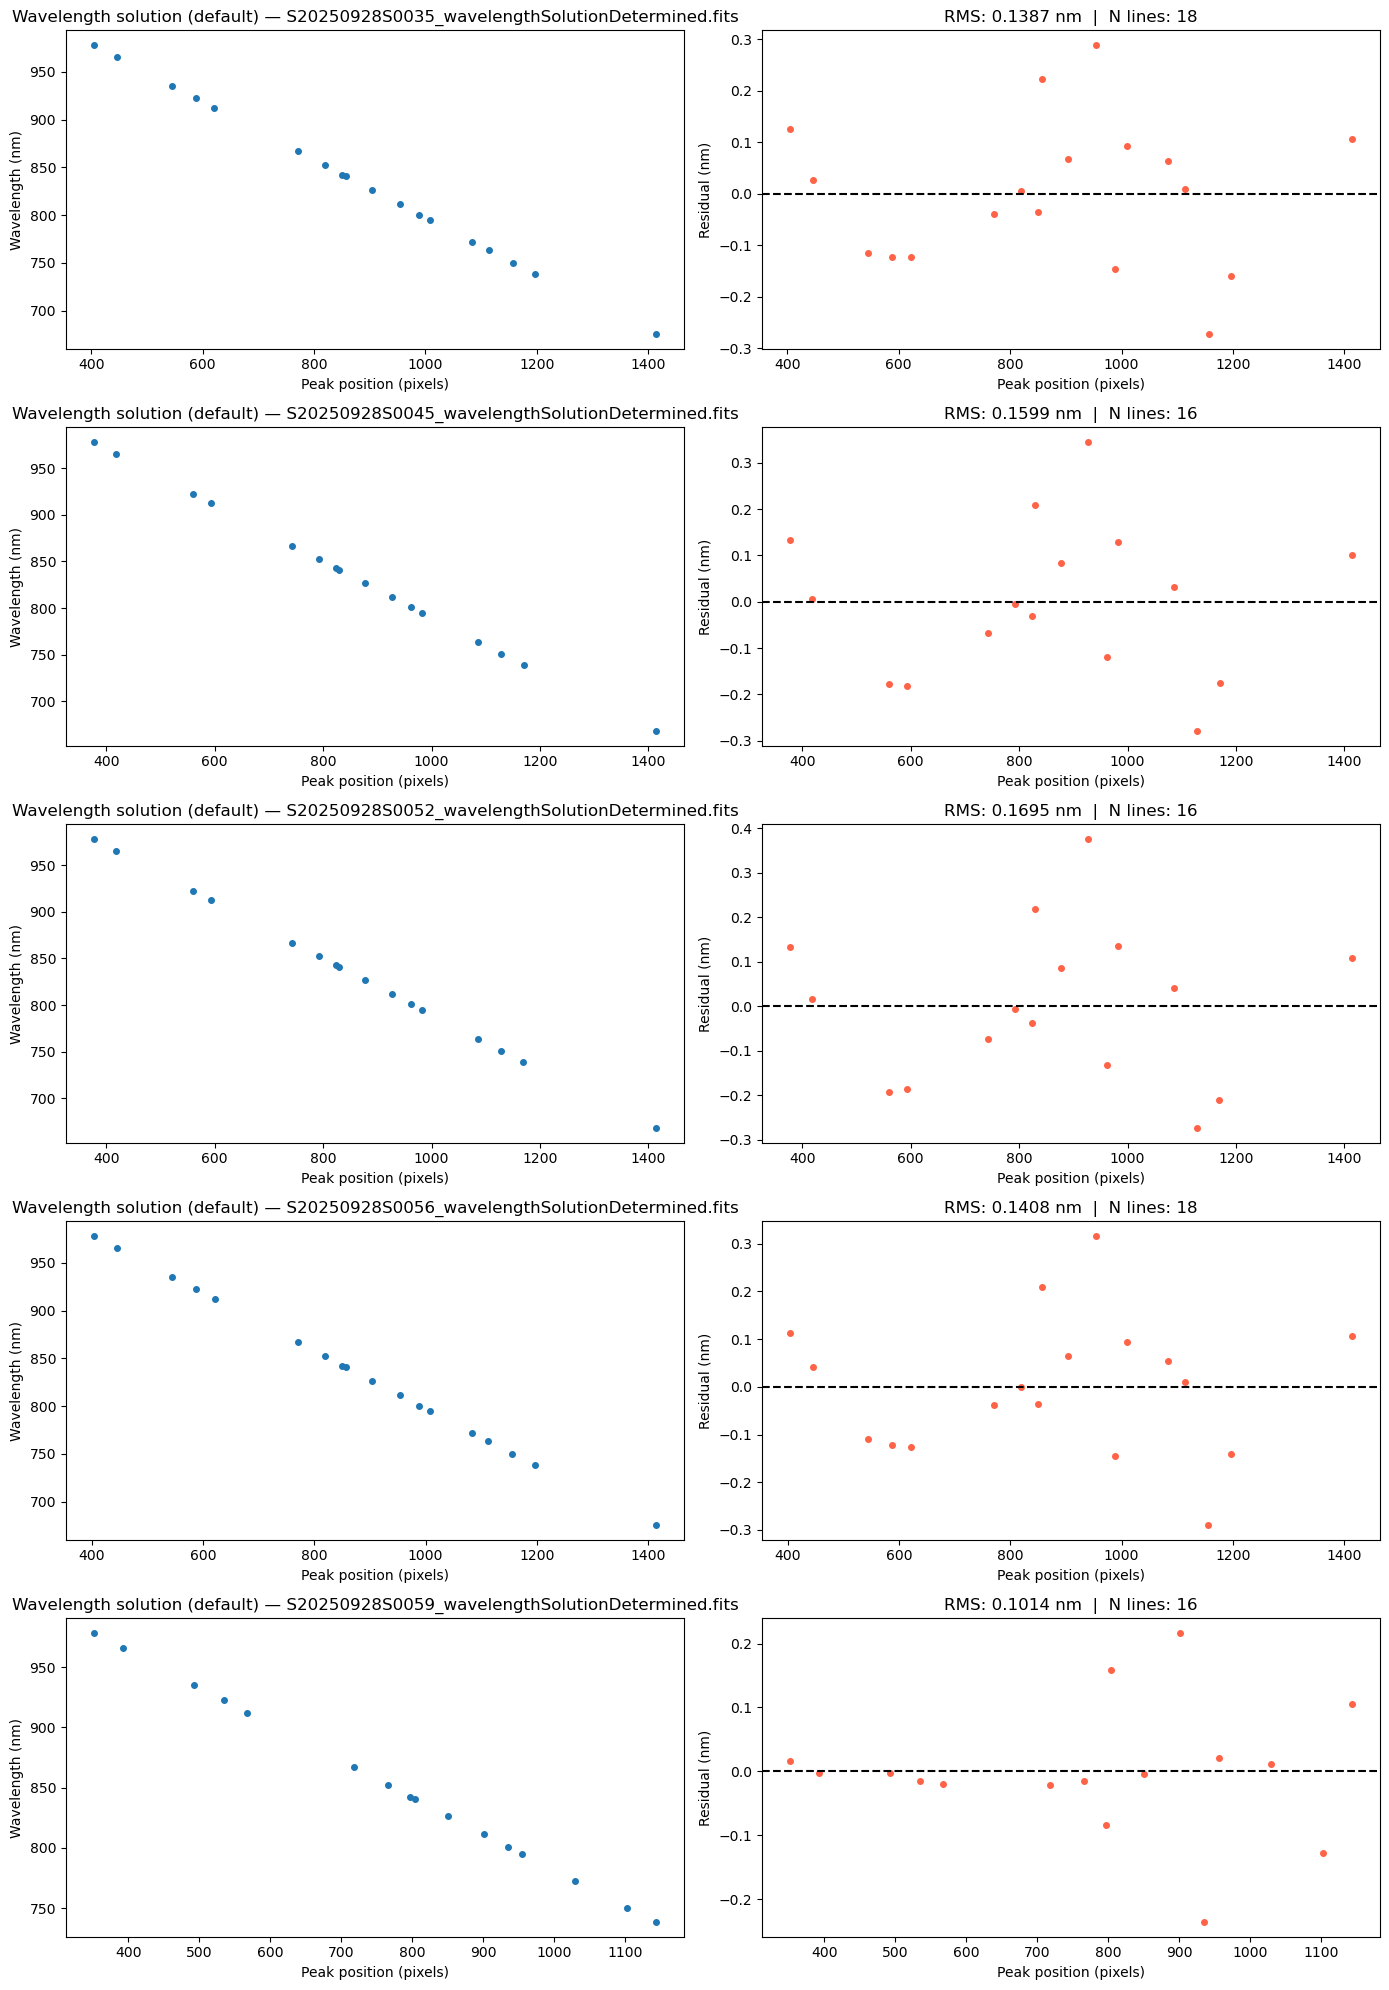

In [ ]:
fresh_ads = [copy.deepcopy(ad) for ad in mosaicked_ads]
for ad in fresh_ads:
    try:
        del ad.HISTORY
    except AttributeError:
        pass

p_default = GMOSSpect(fresh_ads)
p_default.determineWavelengthSolution()

fig, axes = plt.subplots(len(p_default.streams['main']), 2, figsize=(14, 4 * len(p_default.streams['main'])))
if len(p_default.streams['main']) == 1:
    axes = [axes]  # ensure iterable

for idx, ad in enumerate(p_default.streams['main']):
    wavecal = ad[0].WAVECAL
    peaks = np.array(wavecal['peaks'])
    wavelengths = np.array(wavecal['wavelengths'])

    coeffs = np.polyfit(peaks, wavelengths, deg=3)
    fitted = np.polyval(coeffs, peaks)
    residuals = wavelengths - fitted

    axes[idx][0].plot(peaks, wavelengths, 'o', markersize=4)
    axes[idx][0].set_xlabel('Peak position (pixels)')
    axes[idx][0].set_ylabel('Wavelength (nm)')
    axes[idx][0].set_title(f'Wavelength solution (default) — {ad.filename}')

    axes[idx][1].plot(peaks, residuals, 'o', markersize=4, color='tomato')
    axes[idx][1].axhline(0, color='k', linestyle='--')
    axes[idx][1].set_xlabel('Peak position (pixels)')
    axes[idx][1].set_ylabel('Residual (nm)')
    axes[idx][1].set_title(f'RMS: {np.std(residuals):.4f} nm  |  N lines: {len(peaks)}')

plt.tight_layout()
plt.show()

In [ ]:
print(p.params['determineWavelengthSolution'])

OrderedDict({'order': 3, 'lsigma': 3.0, 'hsigma': 3.0, 'niter': 3, 'suffix': '_wavelengthSolutionDetermined', 'center': None, 'nsum': 10, 'min_snr': 10.0, 'min_sep': 2.0, 'weighting': 'local', 'fwidth': None, 'central_wavelength': None, 'dispersion': None, 'linelist': None, 'in_vacuo': False, 'debug_min_lines': '15,20', 'debug_alternative_centers': False, 'interactive': False, 'combine_method': 'mean', 'verbose': False, 'nbright': 0})


In [65]:
p.determineWavelengthSolution()

        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]


### Now, test different permutations of p.determineDistortion()

In [66]:
print(p.params['determineDistortion'])

OrderedDict({'suffix': '_distortionDetermined', 'spatial_order': 3, 'spectral_order': 4, 'id_only': False, 'min_snr': 5.0, 'fwidth': None, 'nsum': 10, 'step': 10, 'max_shift': 0.05, 'max_missed': 5, 'min_line_length': 0.8, 'debug_reject_bad': True, 'debug_min_points_per_trace': 1, 'debug': False})


In [67]:
p.determineDistortion?

Signature: p.determineDistortion(adinputs=None, **params)
Docstring:
Maps the distortion on a detector by tracing lines perpendicular to the
dispersion direction. Then it fits a 2D Chebyshev polynomial to the
fitted coordinates in the dispersion direction. The distortion map does
not change the coordinates in the spatial direction.

The Chebyshev2D model is stored as part of a gWCS object in each
`nddata.wcs` attribute, which gets mapped to a FITS table extension
named `WCS` on disk.


Parameters
----------
adinputs : list of :class:`~astrodata.AstroData`
    Arc data as 2D spectral images with the distortion and wavelength
    solutions encoded in the WCS.

suffix :  str
    Suffix to be added to output files.

spatial_order : int
    Order of fit in spatial direction.

spectral_order : int
    Order of fit in spectral direction.

id_only : bool
    Trace using only those lines identified for wavelength calibration?

min_snr : float
    Minimum signal-to-noise ratio for identifying li

In [82]:
param_grid = {
    "spatial_order":   [2, 3, 4],
    "spectral_order":  [3, 4, 5],
    "min_snr":         [3.0, 5.0, 8.0],
    "step":            [5, 10, 20],
    "max_shift":       [0.03, 0.05, 0.10],
    "max_missed":      [3, 5, 10],
    "min_line_length": [0.6, 0.8, 0.95],
}
focused_grid = {
    "spatial_order":   [2, 3, 4], #3
    "spectral_order":  [3, 4, 5], #4
    "min_snr":         [3.0, 5.0], #5
    "step":            [5, 10], #10
}

def distortion_rms(ad_out):
    """
    Compute distortion RMS in pixels by evaluating the Chebyshev2D model
    (step[0] of the gWCS pipeline: pixels -> distortion_corrected) on a
    grid of pixel positions and measuring residuals from the identity.

    The Chebyshev2D maps (x, y) -> x_corrected. RMS = sqrt(mean((x_corrected - x)^2))
    evaluated across a uniform grid spanning the detector.
    """
    rms_values = []

    for ad in ad_out:
        for i in range(len(ad)):
            ext = ad[i]
            try:
                # Extract the Chebyshev2D — always submodel[1] of step[0]
                cheb = ext.wcs.pipeline[0].transform[1]
                assert type(cheb).__name__ == 'Chebyshev2D', \
                    f"Expected Chebyshev2D, got {type(cheb).__name__}"

                x_min, x_max = cheb.x_domain
                y_min, y_max = cheb.y_domain

                # Evaluate on a uniform grid (~50x50 points is plenty)
                xs = np.linspace(x_min, x_max, 50)
                ys = np.linspace(y_min, y_max, 50)
                xx, yy = np.meshgrid(xs, ys)

                x_corrected = cheb(xx, yy)
                residuals = x_corrected - xx          # deviation from identity
                rms = np.sqrt(np.mean(residuals**2))
                rms_values.append(rms)

            except Exception as e:
                print(f"  Warning: extension {i} failed: {e}")
                rms_values.append(np.nan)

    return float(np.nanmean(rms_values)) if rms_values else np.nan


keys   = list(focused_grid.keys())
values = list(focused_grid.values())
combos = list(itertools.product(*values))

results = [] # list of dicts

print(f"Testing {len(combos)} parameter combinations …\n")

mosaicked_ads = [copy.deepcopy(ad) for ad in p.streams['main']]

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    print(f"[{i+1}/{len(combos)}] {params}", end="  →  ", flush=True)

    fresh_ads = [copy.deepcopy(ad) for ad in mosaicked_ads]
    
    for ad in fresh_ads: # Strip HISTORY to avoid provenance conflict on deepcopied objects
        try:
            del ad.HISTORY
        except AttributeError:
            pass
    
    p_copy = GMOSSpect(fresh_ads)

    try:
        ad_out = p_copy.determineDistortion(**params, debug=False)
        rms    = distortion_rms(ad_out)
    except Exception as e:
        rms = np.nan
        print(f"ERROR: {e}")
    else:
        print(f"RMS = {rms:.4f} px")

    row = {**params, "rms": rms}
    results.append(row)

results.sort(key=lambda r: (np.isnan(r["rms"]), r["rms"])) # sort by RMS

print("\n── Top 5 combinations ──")
for r in results[:5]:
    print(r)

Testing 36 parameter combinations …

[1/36] {'spatial_order': 2, 'spectral_order': 3, 'min_snr': 3.0, 'step': 5}  →  

        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]


RMS = 2.9939 px
[2/36] {'spatial_order': 2, 'spectral_order': 3, 'min_snr': 3.0, 'step': 10}  →  

        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]


RMS = 2.1737 px
[3/36] {'spatial_order': 2, 'spectral_order': 3, 'min_snr': 5.0, 'step': 5}  →  

...

RMS = 2.7499 px
[35/36] {'spatial_order': 4, 'spectral_order': 5, 'min_snr': 5.0, 'step': 5}  →  

        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]


RMS = 3.7612 px
[36/36] {'spatial_order': 4, 'spectral_order': 5, 'min_snr': 5.0, 'step': 10}  →  

        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]


RMS = 3.2518 px

── Top 5 combinations ──
{'spatial_order': 2, 'spectral_order': 3, 'min_snr': 3.0, 'step': 10, 'rms': 2.1737306937318364}
{'spatial_order': 3, 'spectral_order': 3, 'min_snr': 3.0, 'step': 10, 'rms': 2.2993760412892024}
{'spatial_order': 4, 'spectral_order': 3, 'min_snr': 3.0, 'step': 10, 'rms': 2.416195717282951}
{'spatial_order': 2, 'spectral_order': 4, 'min_snr': 3.0, 'step': 10, 'rms': 2.5466662162227394}
{'spatial_order': 2, 'spectral_order': 4, 'min_snr': 5.0, 'step': 5, 'rms': 2.5496442363740517}


In [ ]:
for r in results:
    print(r) # default 3,4,5,10: 2.622

{'spatial_order': 2, 'spectral_order': 3, 'min_snr': 3.0, 'step': 10, 'rms': 2.1737306937318364}
{'spatial_order': 3, 'spectral_order': 3, 'min_snr': 3.0, 'step': 10, 'rms': 2.2993760412892024}
{'spatial_order': 4, 'spectral_order': 3, 'min_snr': 3.0, 'step': 10, 'rms': 2.416195717282951}
{'spatial_order': 2, 'spectral_order': 4, 'min_snr': 3.0, 'step': 10, 'rms': 2.5466662162227394}
{'spatial_order': 2, 'spectral_order': 4, 'min_snr': 5.0, 'step': 5, 'rms': 2.5496442363740517}
{'spatial_order': 3, 'spectral_order': 4, 'min_snr': 5.0, 'step': 5, 'rms': 2.5639101041496284}
{'spatial_order': 3, 'spectral_order': 4, 'min_snr': 3.0, 'step': 10, 'rms': 2.5809225137101137}
{'spatial_order': 2, 'spectral_order': 4, 'min_snr': 5.0, 'step': 10, 'rms': 2.5942140727475667}
{'spatial_order': 3, 'spectral_order': 4, 'min_snr': 5.0, 'step': 10, 'rms': 2.6223246595003507}
{'spatial_order': 4, 'spectral_order': 4, 'min_snr': 5.0, 'step': 5, 'rms': 2.627336326019207}
{'spatial_order': 4, 'spectral_orde

Distortion RMS (test run, default params): 2.6223 px


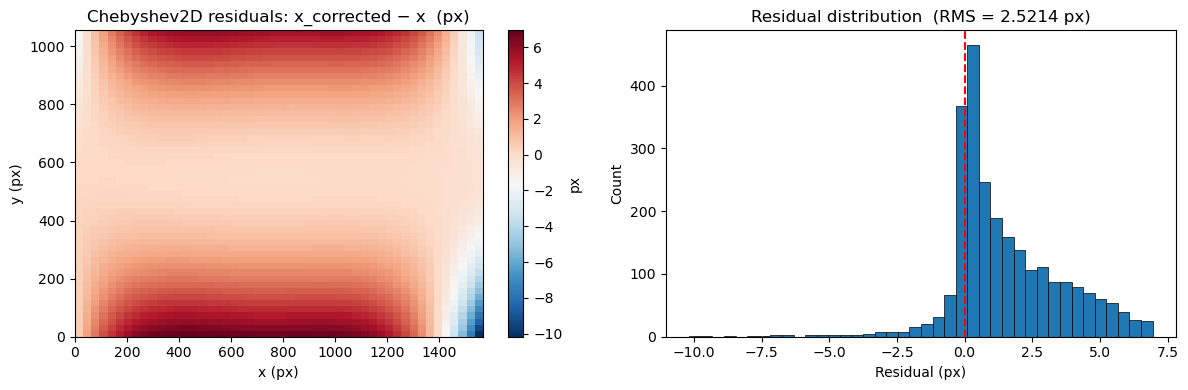

In [83]:
rms = distortion_rms(ad_test)
print(f"Distortion RMS (test run, default params): {rms:.4f} px")

ext = ad_test[0][0]
cheb = ext.wcs.pipeline[0].transform[1]
x_min, x_max = cheb.x_domain
y_min, y_max = cheb.y_domain

xs = np.linspace(x_min, x_max, 50)
ys = np.linspace(y_min, y_max, 50)
xx, yy = np.meshgrid(xs, ys)
residuals = cheb(xx, yy) - xx

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(residuals, origin='lower', aspect='auto',
                    extent=[x_min, x_max, y_min, y_max], cmap='RdBu_r')
axes[0].set_xlabel('x (px)'); axes[0].set_ylabel('y (px)')
axes[0].set_title('Chebyshev2D residuals: x_corrected − x  (px)')
plt.colorbar(im, ax=axes[0], label='px')

axes[1].hist(residuals.ravel(), bins=40, edgecolor='k', linewidth=0.5)
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_xlabel('Residual (px)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual distribution  (RMS = {np.sqrt(np.mean(residuals**2)):.4f} px)')

plt.tight_layout()
plt.show()

In [89]:
# df = pd.DataFrame(results)
# df_valid = df.dropna(subset=["rms"])

# fig, axes = plt.subplots(1, len(keys), figsize=(4 * len(keys), 4), sharey=False)
# fig.suptitle("determineDistortion() – RMS vs. each parameter\n(others averaged)", fontsize=12)

# for ax, key in zip(axes, keys):
#     grouped = df_valid.groupby(key)["rms"].agg(["mean", "std"]).reset_index()
#     ax.errorbar(
#         grouped[key].astype(str),
#         grouped["mean"],
#         yerr=grouped["std"].fillna(0),
#         fmt="o-",
#         capsize=4,
#         linewidth=1.5,
#     )
#     ax.set_xlabel(key, fontsize=10)
#     ax.set_ylabel("Mean RMS (px)" if ax is axes[0] else "")
#     ax.set_title(key)
#     ax.grid(True, linestyle="--", alpha=0.4)
#     plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# plt.tight_layout()
# plt.savefig("distortion_param_sweep.png", dpi=120, bbox_inches="tight")
# plt.show()
# print("Figure saved → distortion_param_sweep.png")


# # ── 5. 2-D heat-maps for pairs of parameters (optional deep-dive) ─────────────
# pair_keys = [("spatial_order", "spectral_order"), ("step", "min_snr")]

# fig2, axes2 = plt.subplots(1, len(pair_keys), figsize=(6 * len(pair_keys), 5))
# fig2.suptitle("RMS heat-maps (mean over remaining params)", fontsize=12)

# for ax, (kx, ky) in zip(axes2, pair_keys):
#     pivot = df_valid.pivot_table(index=ky, columns=kx, values="rms", aggfunc="mean")
#     im = ax.imshow(pivot.values, aspect="auto", origin="lower",
#                    cmap="viridis_r")
#     ax.set_xticks(range(len(pivot.columns)))
#     ax.set_xticklabels(pivot.columns)
#     ax.set_yticks(range(len(pivot.index)))
#     ax.set_yticklabels(pivot.index)
#     ax.set_xlabel(kx); ax.set_ylabel(ky)
#     ax.set_title(f"{kx} vs {ky}")
#     fig2.colorbar(im, ax=ax, label="Mean RMS (px)")

# plt.tight_layout()
# plt.savefig("distortion_param_heatmaps.png", dpi=120, bbox_inches="tight")
# plt.show()
# print("Heat-map saved → distortion_param_heatmaps.png")


# # ── 6. Print the best parameter set ──────────────────────────────────────────
# best = results[0]
# print("\n── Optimal parameters ──")
# for k, v in best.items():
#     print(f"  {k}: {v}")

In [61]:
p.determineDistortion()
p.storeProcessedArc()
p.writeOutputs()

        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_frames]
        Use numpy.iterable() instead. [gwcs.coordinate_